In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import measure as ms    # measure.py

In [2]:
class KNN:
    def __init__(self, filePath: str, k: int):
        self.data = pd.read_csv(filePath)
        self.k = k
        self.preprocess()
        self.split_data()


    def predict(self):
        predictions = [self.predict_single(x) for x in self.X_test]
        return np.array(predictions)


    def preprocess(self):
        self.data = self.data.sample(frac=1)
                
        self.X = self.data.drop(columns='target').to_numpy()
        self.Y = self.data.filter(like='target').to_numpy()

        self.X = (self.X - self.X.mean(axis = 0)) / self.X.std(axis = 0)


    def split_data(self):
        self.split_index = int(0.8 * self.X.shape[0])
        
        self.X_train = self.X[:self.split_index]
        self.X_test  = self.X[self.split_index:]

        self.Y_train = self.Y[:self.split_index]
        self.Y_test  = self.Y[self.split_index:]


    def distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))


    def predict_single(self, x):
        distances = [self.distance(x, xt) for xt in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_targets = self.Y_train[k_indices]
        positive_count = np.sum(k_targets)
        return 1 if positive_count > self.k / 2 else 0


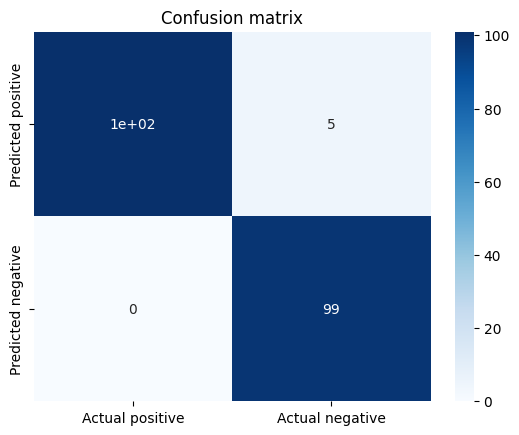

Accuracy: 0.98
Precision: 1.0
Recall: 0.95
Specificity: 1.0
F1 score: 0.98


In [3]:
if __name__ == "__main__":
    knn = KNN("dataset/heart.csv", 3)
    
    predictions = knn.predict()
    tp, fp, fn, tn = ms.getConfusionMatrixEntries(predictions, knn.Y_test)
    ms.confusionMatrix(tp, fp, fn, tn)

In [4]:
class NaiveBayes:
    def __init__(self, filePath):
        self.data = pd.read_csv(filePath);
        self.preprocess()
        self.split_data()
        self.get_probs()
        
    
    def preprocess(self):
        self.data = self.data.sample(frac=1)
                
        self.X = self.data.drop(columns='target').to_numpy()
        self.Y = self.data.filter(like='target').to_numpy()

    
    def split_data(self):
        self.split_index = int(0.8 * self.X.shape[0])
        
        self.X_train = self.X[:self.split_index]
        self.X_test  = self.X[self.split_index:]
        
        self.Y_train = self.Y[:self.split_index]
        self.Y_test  = self.Y[self.split_index:]


    def get_probs(self):
        def get_discrete_probs(arr: np.ndarray):
            unique, counts = np.unique(arr, return_counts=True)
            freqs = counts / arr.size
            
            return tuple(counts)

        #stores the probabilities of each value given target == 1 or 0
        #some fields are continuous; the mean and variance are stored instead
        #all discrete fields have integral values starting from 0; hence, they can be used as indices

        true_indices = np.nonzero(self.Y_train)[0]
        true_cases = self.X_train[true_indices]
        
        false_indices = np.setdiff1d(range(self.Y_train.shape[0]), true_indices)
        false_cases = self.X_train[false_indices]
        
        self.true_prob = true_cases.shape[0] / self.X_train.shape[0]
        self.false_prob = false_cases.shape[0] / self.X_train.shape[0]
        
        #target == 1
        self.true_probs = [None] * 13

        true_means = true_cases.mean(axis = 0)
        true_vars = true_cases.var(axis = 0)

        self.true_probs[ 0] = (true_means[0], true_vars[0])          #age
        self.true_probs[ 1] = get_discrete_probs(self.X_train[:, 1]) #sex (0, 1)
        self.true_probs[ 2] = get_discrete_probs(self.X_train[:, 2]) #cp (0, 1, 2, 3)
        self.true_probs[ 3] = (true_means[3], true_vars[3])          #trestbps
        self.true_probs[ 4] = (true_means[4], true_vars[4])          #chol
        self.true_probs[ 5] = get_discrete_probs(self.X_train[:, 5]) #fbs (0, 1)
        self.true_probs[ 6] = get_discrete_probs(self.X_train[:, 6]) #restecg (0, 1, 2)
        self.true_probs[ 7] = (true_means[7], true_vars[7])          #thalach
        self.true_probs[ 8] = get_discrete_probs(self.X_train[:, 8]) #exang
        self.true_probs[ 9] = (true_means[9], true_vars[9])          #oldpeak
        self.true_probs[10] = get_discrete_probs(self.X_train[:,10]) #slope
        self.true_probs[11] = get_discrete_probs(self.X_train[:,11]) #ca
        self.true_probs[12] = get_discrete_probs(self.X_train[:,12]) #thal

        #target == 0
        self.false_probs = [None] * 13

        false_means = false_cases.mean(axis = 0)
        false_vars = false_cases.var(axis = 0)

        self.false_probs[ 0] = (false_means[0], false_vars[0])        #age
        self.false_probs[ 1] = get_discrete_probs(self.X_train[:, 1]) #sex (0, 1)
        self.false_probs[ 2] = get_discrete_probs(self.X_train[:, 2]) #cp (0, 1, 2, 3)
        self.false_probs[ 3] = (false_means[3], false_vars[3])        #trestbps
        self.false_probs[ 4] = (false_means[4], false_vars[4])        #chol
        self.false_probs[ 5] = get_discrete_probs(self.X_train[:, 5]) #fbs (0, 1)
        self.false_probs[ 6] = get_discrete_probs(self.X_train[:, 6]) #restecg (0, 1, 2)
        self.false_probs[ 7] = (false_means[7], false_vars[7])        #thalach
        self.false_probs[ 8] = get_discrete_probs(self.X_train[:, 8]) #exang
        self.false_probs[ 9] = (false_means[9], false_vars[9])        #oldpeak
        self.false_probs[10] = get_discrete_probs(self.X_train[:,10]) #slope
        self.false_probs[11] = get_discrete_probs(self.X_train[:,11]) #ca
        self.false_probs[12] = get_discrete_probs(self.X_train[:,12]) #thal
        
        
    def predict(self):
        predictions = [self.predict_single(x) for x in self.X_test]
        return np.array(predictions)

        
    def predict_single(self, x):
        def pdf(value, params):
            mean, var = params
            return norm.pdf(value, mean, var)


        def pmf(value, dist):
            return dist[int(value)]
        

        true_prob = self.true_prob * (  pdf(x[ 0], self.true_probs[ 0]) 
                                      * pmf(x[ 1], self.true_probs[ 1])
                                      * pmf(x[ 2], self.true_probs[ 2])
                                      * pdf(x[ 3], self.true_probs[ 3])
                                      * pdf(x[ 4], self.true_probs[ 4])
                                      * pmf(x[ 5], self.true_probs[ 5])
                                      * pmf(x[ 6], self.true_probs[ 6])
                                      * pdf(x[ 7], self.true_probs[ 7])
                                      * pmf(x[ 8], self.true_probs[ 8])
                                      * pdf(x[ 9], self.true_probs[ 9])
                                      * pmf(x[10], self.true_probs[10])
                                      * pmf(x[11], self.true_probs[11])
                                      * pmf(x[12], self.true_probs[12]))

        false_prob = self.false_prob * (  pdf(x[ 0], self.false_probs[ 0])
                                        * pmf(x[ 1], self.false_probs[ 1])
                                        * pmf(x[ 2], self.false_probs[ 2])
                                        * pdf(x[ 3], self.false_probs[ 3])
                                        * pdf(x[ 4], self.false_probs[ 4])
                                        * pmf(x[ 5], self.false_probs[ 5])
                                        * pmf(x[ 6], self.false_probs[ 6])
                                        * pdf(x[ 7], self.false_probs[ 7])
                                        * pmf(x[ 8], self.false_probs[ 8])
                                        * pdf(x[ 9], self.false_probs[ 9])
                                        * pmf(x[10], self.false_probs[10])
                                        * pmf(x[11], self.false_probs[11])
                                        * pmf(x[12], self.false_probs[12]))

        return 1 if true_prob > false_prob else 0



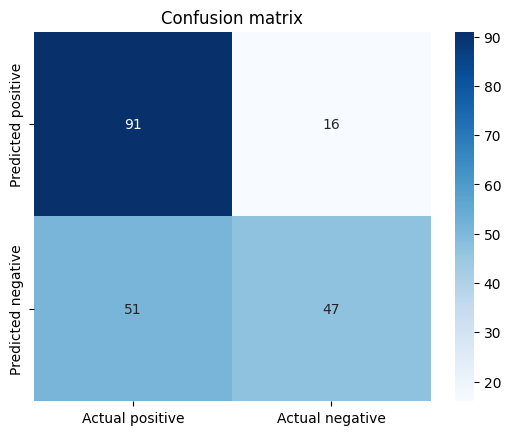

Accuracy: 0.67
Precision: 0.64
Recall: 0.85
Specificity: 0.48
F1 score: 0.73


In [5]:
if __name__ == "__main__":
    nb = NaiveBayes("dataset/heart.csv")
    predictions = nb.predict()
    tp, fp, fn, tn = ms.getConfusionMatrixEntries(predictions, nb.Y_test)
    ms.confusionMatrix(tp, fp, fn, tn)